# Sanity checks: filtered European panel

Checks the filtered European data (`22_filter_prices_eu.py` → `40_build_monthly_universe.py --region EU`)
against outside benchmarks and for internal consistency:

1. **Universe** per country over time (stocks, market cap).
2. **Fama-French Europe market.** French's Europe region covers 16 countries (AT BE DK FI FR DE GR IE IT NL NO PT ES
   SE CH UK), returns in **USD**, RF = one-month U.S. T-bill. We rebuild it as the value-weighted (lagged EUR market
   cap) return of these 16 countries, convert EUR → USD at month-end rates, and compare with `Mkt-RF + RF`.
   Section 2b tests the currency assumption empirically (USD vs. EUR version of our series).
3. **Datastream Total Market indices per country** (`TOTMK..`, `RI~E`, monthly): country VW returns vs. the
   index (needs the index download; skipped until the file exists).
4. **Local vs. EUR returns**: identical after euro adoption, different only for non-euro quotes.
5. Optional: **Top 600** by market cap (STOXX 600-like, no free-float weights) vs. a STOXX 600 / MSCI Europe series.

**Expectations (VW, monthly):** correlation with FF Europe ≳ 0.98, beta ≈ 1, alpha not significant, tracking
error of a few percent per year (FF uses Datastream/Worldscope too but other filters and a different universe
before 1990s coverage expands). Per-country correlations with the Datastream indices ≳ 0.95 for large markets;
small markets (CY, MT, Baltics, BG, RO) are noisier.

Functions: `src/datastream/eu_evaluation.py` (European helpers) and `src/datastream/evaluation.py` (comparison).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datastream import eu_evaluation as eu
from datastream import evaluation as ev
from datastream.ff_data import get_ff_region_factors

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)

# ── configuration ───────────────────────────────────────────────────────────────────────────────────
DATA_PATH = Path("D:/Datastream/PriceData/EU/processed")
PENNY_PERCENTILE = 0.25
UNIVERSE_FILE = DATA_PATH / f"monthly_universe_{PENNY_PERCENTILE}.parquet"
FX_FILE = Path("D:/Datastream/Benchmarks/DEXUSEU.csv")        # FRED daily USD per EUR (EXUSEU = monthly averages)
TOTMK_FILE = Path("D:/Datastream/Benchmarks/EU_TOTMK_RI_E.xlsx")  # Datastream Total Market indices, RI~E, monthly
STOXX_FILE = Path("D:/Datastream/Benchmarks/STOXX600_RI_E.xlsx")  # optional
COUNTRIES_FILE = Path("../config/eu_countries.csv")
START = "1999-01"                                              # analysis start (download starts 1992-12)
HAC_LAGS = 6

## 1. Data and universe

In [2]:
uni = pd.read_parquet(UNIVERSE_FILE)
m = eu.monthly_returns(uni)
m = m[m["Month"] >= pd.Period(START, "M")]
print(f"{len(m):,} stock-months, {m['DSCD'].nunique():,} stocks, {m['Country'].nunique()} countries, "
      f"{m['Month'].min()} to {m['Month'].max()}")

countries = pd.read_csv(COUNTRIES_FILE)
countries["country_uc"] = countries["country"].str.upper()
euro_adoption = countries.dropna(subset=["euro_adoption"]).set_index("country_uc")["euro_adoption"].to_dict()
missing_ff = sorted(set(eu.FF_EUROPE_COUNTRIES) - set(m["Country"].unique()))
print("FF Europe countries missing in our data:", missing_ff or "none")

1,611,890 stock-months, 15,311 stocks, 31 countries, 1999-01 to 2025-12
FF Europe countries missing in our data: none


Month,2000-12,2005-12,2010-12,2015-12,2020-12,2025-12,2025-12
Country,,,,,,,
AUSTRIA,69,56,57,49,44,44,44
BELGIUM,126,116,114,95,91,83,83
BULGARIA,7,12,77,68,70,80,80
CROATIA,6,67,93,77,55,43,43
CYPRUS,60,78,57,26,25,21,21
CZECH REPUBLIC,66,19,10,11,9,11,11
DENMARK,162,130,146,114,116,106,106
ESTONIA,13,10,12,12,14,22,22
FINLAND,120,113,102,108,121,135,135


Month,2000-12,2005-12,2010-12,2015-12,2020-12,2025-12,2025-12
Country,,,,,,,
AUSTRIA,0.3000,1.1000,1.0000,0.7000,0.7000,0.9000,0.9000
BELGIUM,2.0000,2.7000,2.3000,3.3000,2.4000,2.4000,2.4000
BULGARIA,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
CROATIA,0.0000,0.6000,0.2000,0.1000,0.1000,0.2000,0.2000
CYPRUS,0.1000,0.1000,0.1000,0.0000,0.0000,0.0000,0.0000
CZECH REPUBLIC,0.1000,0.3000,0.3000,0.2000,0.1000,0.3000,0.3000
DENMARK,1.2000,1.6000,2.1000,2.9000,3.8000,3.0000,3.0000
ESTONIA,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
FINLAND,3.6000,2.2000,2.3000,2.0000,2.3000,1.8000,1.8000


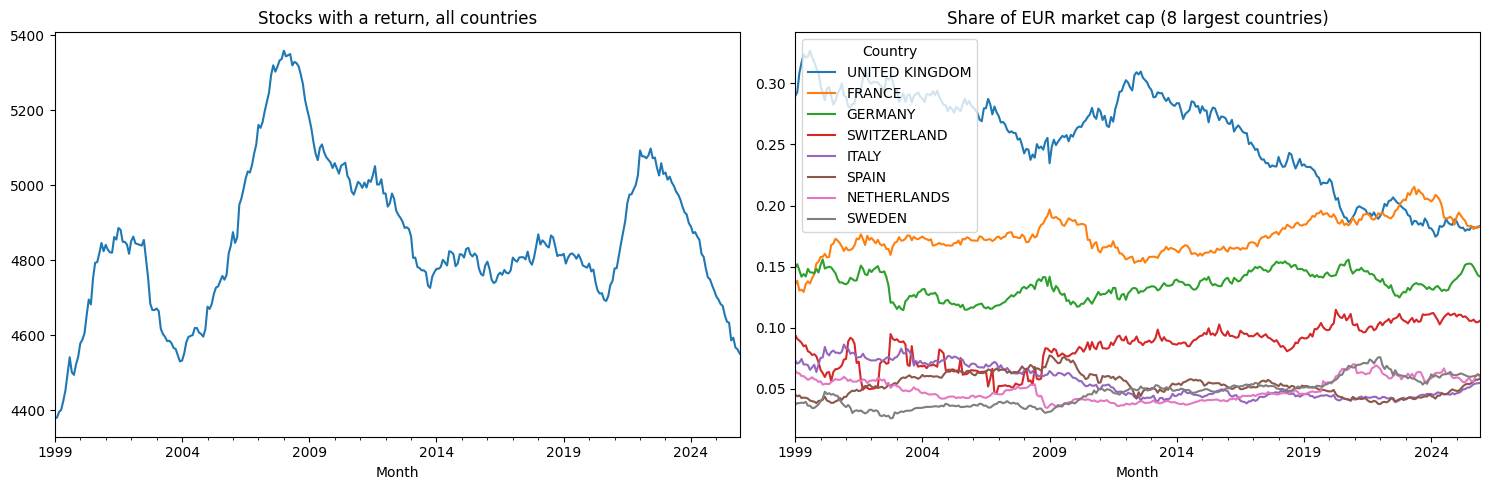

In [3]:
ub = eu.universe_by_country(m)
n_stocks = ub.pivot(index="Month", columns="Country", values="n_stocks")
me_share = ub.pivot(index="Month", columns="Country", values="me_eur")
me_share = me_share.div(me_share.sum(axis=1), axis=0)

# snapshot: every 5 years, number of stocks and share of European market cap
snap = [p for p in n_stocks.index if p.month == 12 and p.year % 5 == 0] + [n_stocks.index.max()]
display(n_stocks.loc[snap].T.fillna(0).astype(int))
display((100 * me_share.loc[snap].T).round(1))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
n_stocks.sum(axis=1).plot(ax=ax[0], title="Stocks with a return, all countries")
top = me_share.mean().nlargest(8).index
me_share[top].plot(ax=ax[1], title="Share of EUR market cap (8 largest countries)")
plt.tight_layout()

Look for: sudden jumps in the number of stocks of a country (list or exchange mapping problems), countries
entering late (coverage) and market-cap shares that do not match known market sizes (UK, FR, DE, CH largest).

## 2. Europe-16 vs. Fama-French Europe market

In [4]:
ff_eu = get_ff_region_factors("Europe", "monthly")
fx = eu.fx_month_end(FX_FILE)                                  # warns if the file holds monthly averages
vw_eur = eu.vw_returns(m, "ret_eur", countries=eu.FF_EUROPE_COUNTRIES).rename("VW_EUR")
vw_usd = eu.eur_to_usd(vw_eur, fx).rename("VW_USD")
print(f"FF Europe {ff_eu.index.min()} to {ff_eu.index.max()}, FX {fx.index.min()} to {fx.index.max()}")

stats_usd, res_usd = ev.compare_to_market(vw_usd, ff_eu, periods_per_year=12, hac_lags=HAC_LAGS)
stats_usd_tab = pd.Series(stats_usd, name="VW Europe-16 (USD)").to_frame()
stats_usd_tab

FF Europe 1990-07 to 2026-08, FX 1999-01 to 2026-10


,VW Europe-16 (USD)
n_obs,323
start,1999-02
end,2025-12
corr,0.9982
alpha,-0.0001
alpha_annual,-0.0014
alpha_t_hac,-1.1643
beta,1.0018
beta_t_hac,240.3948
r2,0.9963


### 2b. Currency of the FF Europe returns

If FF Europe is in USD, our USD series correlates clearly more with `Mkt-RF + RF` than our EUR series (EUR/USD
volatility is about 8-10% p.a., so the EUR version should have a visibly lower correlation and a tracking
error of roughly that size).

In [5]:
ff_mkt = (ff_eu["Mkt-RF"] + ff_eu["RF"]).rename("FF_Mkt")
cur = pd.concat([vw_usd, vw_eur, ff_mkt], axis=1, join="inner").dropna()
currency_tab = pd.DataFrame({
    "corr_with_FF": [cur["VW_USD"].corr(cur["FF_Mkt"]), cur["VW_EUR"].corr(cur["FF_Mkt"])],
    "tracking_error_annual": [(cur["VW_USD"] - cur["FF_Mkt"]).std() * np.sqrt(12),
                              (cur["VW_EUR"] - cur["FF_Mkt"]).std() * np.sqrt(12)],
}, index=["our VW in USD", "our VW in EUR"])
currency_tab

,corr_with_FF,tracking_error_annual
our VW in USD,0.9982,0.0109
our VW in EUR,0.8561,0.0926


,n_obs,corr,beta,alpha_annual,alpha_t_hac,tracking_error_annual,mean_diff_annual
period,,,,,,,
1999-2007,107,0.9972,1.0083,-0.0016,-0.6318,0.0115,-0.0010
2008-2012,60,0.9988,0.9880,-0.0006,-0.2305,0.0128,-0.0005
2013-2019,84,0.9978,1.0155,-0.0020,-0.8737,0.0088,-0.0009
2020-,72,0.9985,1.0109,-0.0037,-1.7393,0.0106,-0.0028


,Portfolio,FF_Mkt,Diff
2010-12,0.0765,0.0905,-0.0140
2011-01,0.0486,0.0369,0.0117
2022-12,0.0020,-0.0076,0.0096
2022-11,0.1198,0.1293,-0.0095
1999-09,-0.0083,0.0007,-0.0090
2000-12,0.0702,0.0618,0.0084
2002-06,-0.0319,-0.0235,-0.0084
2000-02,0.0712,0.0630,0.0082
2002-07,-0.0965,-0.1044,0.0079
2008-12,0.0592,0.0670,-0.0078


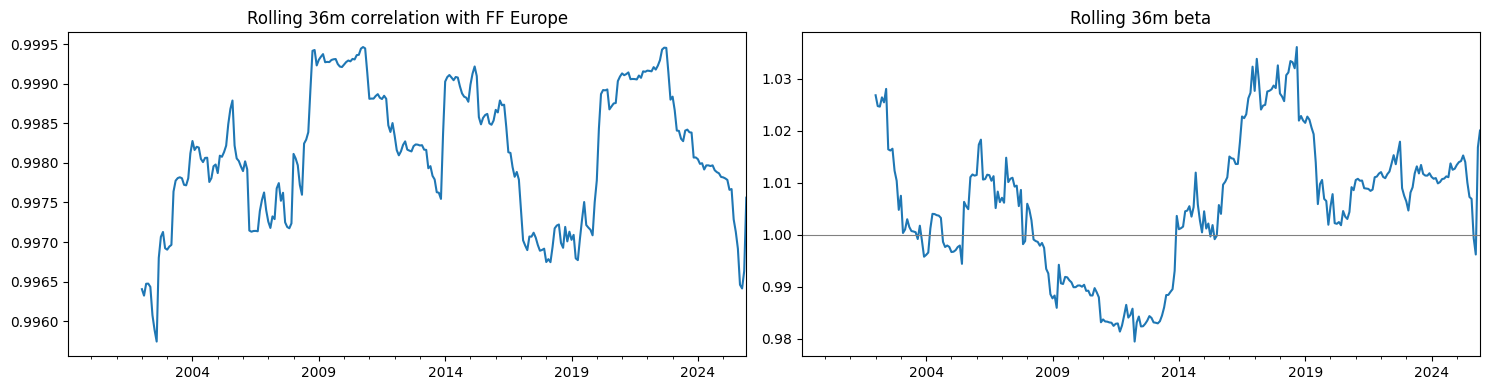

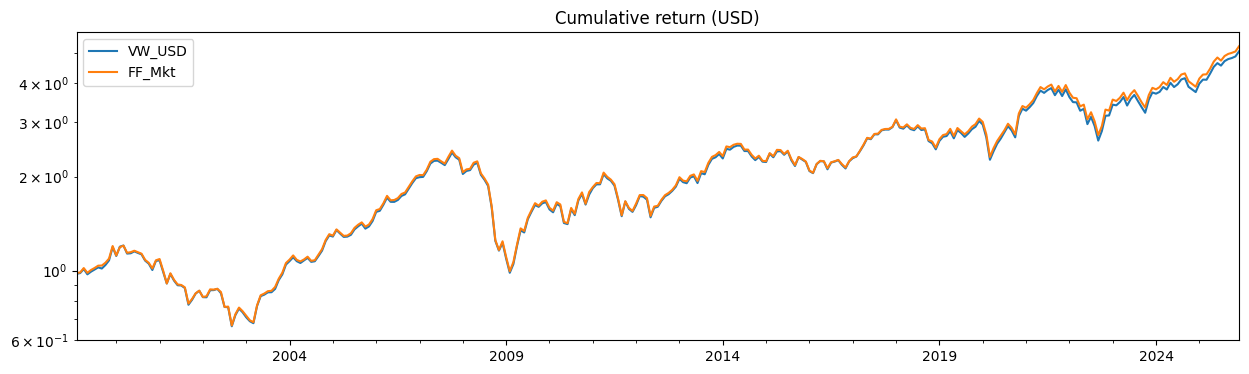

In [6]:
periods = [("1999-2007", "1999-01", "2007-12"), ("2008-2012", "2008-01", "2012-12"),
           ("2013-2019", "2013-01", "2019-12"), ("2020-", "2020-01", str(ff_eu.index.max()))]
subperiods = ev.subperiod_table(vw_usd, ff_eu, periods, periods_per_year=12, hac_lags=HAC_LAGS)
display(subperiods[["n_obs", "corr", "beta", "alpha_annual", "alpha_t_hac", "tracking_error_annual", "mean_diff_annual"]])

roll = ev.rolling_fit(vw_usd, ff_eu, window=36)
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
roll["corr"].plot(ax=ax[0], title="Rolling 36m correlation with FF Europe")
roll["beta"].plot(ax=ax[1], title="Rolling 36m beta")
ax[1].axhline(1, color="grey", lw=0.8)
plt.tight_layout()

cum = pd.concat([vw_usd, ff_mkt], axis=1, join="inner").dropna()
(1 + cum).cumprod().plot(logy=True, figsize=(15, 4), title="Cumulative return (USD)")
deviations = ev.largest_deviations(vw_usd, ff_eu, n=10)
deviations

Large single-month deviations point to data problems in a few big stocks (check the stocks with the largest
contribution in that month below) or to differences in the universe (FF excludes some countries' small caps in
early years).

In [7]:
def contributions(m, month, n=10, countries=eu.FF_EUROPE_COUNTRIES):
    """Largest absolute contributions (weight × return) to the VW return of one month."""
    d = m[(m["Month"] == pd.Period(month, "M")) & m["Country"].isin(countries)].dropna(subset=["ret_eur", "lag_me_eur"])
    d = d.assign(weight=d["lag_me_eur"] / d["lag_me_eur"].sum())
    d = d.assign(contribution=d["weight"] * d["ret_eur"])
    return d.reindex(d["contribution"].abs().sort_values(ascending=False).index)[
        ["DSCD", "Country", "lag_me_eur", "weight", "ret_eur", "ret_local", "contribution"]].head(n)

worst = ev.largest_deviations(vw_usd, ff_eu, n=1).index[0]
print("Month with the largest deviation:", worst)
contrib = contributions(m, worst)
contrib

Month with the largest deviation: 2010-12


,DSCD,Country,lag_me_eur,weight,ret_eur,ret_local,contribution
1433365,885164,SWITZERLAND,"108,257.0934",0.0148,0.0760,0.0319,0.0011
936406,257544,NORWAY,"48,557.1793",0.0066,0.1636,0.1259,0.0011
631916,902192,GERMANY,"77,524.3800",0.0106,0.0987,0.0987,0.0010
1730543,903076,UNITED KINGDOM,"44,538.3380",0.0061,0.1536,0.1826,0.0009
1440226,929724,SWITZERLAND,"145,687.4136",0.0199,0.0465,0.0037,0.0009
912774,899069,NETHERLANDS,"37,906.8000",0.0052,0.1686,0.1686,0.0009
1556666,31347F,UNITED KINGDOM,"82,124.6394",0.0112,0.0775,0.1046,0.0009
1699337,900995,UNITED KINGDOM,"95,794.0338",0.0131,0.0662,0.0930,0.0009
1477592,15322M,UNITED KINGDOM,"45,826.1738",0.0062,0.1367,0.1652,0.0009
404576,912398,FRANCE,"87,631.3100",0.0119,0.0626,0.0626,0.0007


## 3. Countries vs. Datastream Total Market indices

Download (Datastream, monthly, from 1992-12-31): `RI~E` of the **"<COUNTRY>-DS Market"** index of every sample
country into one sheet, first column dates (in Navigator: Category *Equity Indices*, search `DS Market`). The
column names as exported (`UK-DS Market`, `SWITZ-DS Market`, `CZECH REP.-DS Market`, ...) are mapped to our country
names by `eu_evaluation.ds_market_country`; new abbreviations go into `DS_MARKET_NAME_ALIASES`.

In [8]:
vw_country = eu.vw_returns(m, "ret_eur", by="Country")
if TOTMK_FILE.exists():
    idx = eu.index_returns(TOTMK_FILE)
    # columns are named '<COUNTRY>-DS Market' (e.g. 'UK-DS Market'); mapped to our Country names
    idx_by_country = eu.ds_market_by_country(idx, countries=vw_country.columns)
    other = [c for c in idx.columns if eu.ds_market_country(c) not in vw_country.columns]
    if other:
        print("Index columns without a country in our data (ignored):", other)
    print("Countries without index:", sorted(set(vw_country.columns) - set(idx_by_country.columns)) or "none")
    if idx_by_country.empty:
        raise ValueError(f"No '<COUNTRY>-DS Market' column matched. Columns in the file: {list(idx.columns)}")
    cmp = eu.compare_series(vw_country, idx_by_country, {c: c for c in idx_by_country.columns})
    cmp = cmp.join(n_stocks.median().rename("median_n_stocks"))
    display(cmp.sort_values("corr"))

    # diagnostics for low correlations: date convention of the file and shifted correlations
    date_profile = eu.raw_date_profile(TOTMK_FILE)
    display(date_profile.to_frame("index file dates"))
    lead_lag = eu.lead_lag_corr(vw_country, idx_by_country)
    display(lead_lag.round(3))
else:
    print(f"{TOTMK_FILE} not found: download the Total Market indices first (section 3 skipped).")

Index columns without a country in our data (ignored): ['SRI LANKA-DS Market']
Countries without index: ['CYPRUS', 'ICELAND']


,benchmark,n_months,start,end,corr,beta,tracking_error_annual,mean_diff_annual,median_n_stocks
series,,,,,,,,,
LUXEMBOURG,LUXEMBOURG,324,1999-01,2025-12,0.5700,0.5099,0.1571,0.0276,9.0000
SLOVAKIA,SLOVAKIA,237,2006-04,2025-12,0.6574,1.3463,0.1688,-0.0354,6.0000
LATVIA,LATVIA,324,1999-01,2025-12,0.7612,0.6962,0.1628,-0.0457,13.0000
ROMANIA,ROMANIA,324,1999-01,2025-12,0.7769,0.7588,0.2093,-0.0221,95.0000
LITHUANIA,LITHUANIA,324,1999-01,2025-12,0.8030,0.8174,0.1191,-0.0025,23.0000
ESTONIA,ESTONIA,324,1999-01,2025-12,0.8208,0.7548,0.1374,0.0095,13.0000
CROATIA,CROATIA,242,2005-11,2025-12,0.8911,0.8777,0.0812,-0.0257,57.5000
BULGARIA,BULGARIA,302,2000-11,2025-12,0.9222,0.9330,0.1071,0.0233,71.0000
IRELAND,IRELAND,324,1999-01,2025-12,0.9550,0.9663,0.0582,-0.0046,32.0000


,index file dates
n_dates,8808
first,1993-01-01
last,2026-10-06
share_month_end,0.0328
share_day_1,0.0330
median_days_between,1.0000
unparsed_rows,0


,lag_-2,lag_-1,lag_+0,lag_+1,lag_+2,best_lag
AUSTRIA,0.0960,0.1920,0.9840,0.1900,0.0720,0
BELGIUM,-0.0030,0.1630,0.9880,0.1510,-0.0120,0
BULGARIA,0.2100,0.2270,0.9220,0.1930,0.1880,0
CROATIA,0.0960,0.3280,0.8910,0.2930,0.0610,0
CZECH REPUBLIC,0.0120,0.0950,0.9620,0.1240,-0.0100,0
DENMARK,-0.0060,0.1160,0.9920,0.1100,-0.0090,0
ESTONIA,0.0390,0.1860,0.8210,0.1670,0.0440,0
FINLAND,-0.0520,0.2200,0.9850,0.2050,-0.0730,0
FRANCE,-0.0300,0.0840,0.9940,0.0470,-0.0530,0
GERMANY,0.0030,0.0610,0.9930,0.0470,-0.0200,0


Look for: correlations clearly below 0.95 in large markets, betas far from 1 and large mean differences.
Datastream's total market indices hold a representative sample of the largest stocks (not all), so small caps
explain some tracking error, but not a low correlation.

## 4. Local vs. EUR returns

In [9]:
lve = eu.local_vs_eur(m, euro_adoption)
display(lve.pivot(index="Country", columns="period", values="share_differs").round(3))

period,after,before,no euro
Country,,,
AUSTRIA,0.0000,NaN,NaN
BELGIUM,0.0000,NaN,NaN
BULGARIA,NaN,0.0800,NaN
CROATIA,0.0000,0.4520,NaN
CYPRUS,0.0000,0.0560,NaN
CZECH REPUBLIC,NaN,NaN,0.9990
DENMARK,NaN,NaN,0.9970
ESTONIA,0.0000,0.0360,NaN
FINLAND,0.0000,NaN,NaN


Expected: `after` ≈ 0 for euro countries (legacy-currency lines are fixed multiples after adoption);
`before` and `no euro` ≈ 1 (exchange-rate movements), except for pegged currencies (DKK, BGN, Baltic currencies)
where differences are tiny but still > 1e-6. Non-zero `after` shares point to lines quoted in a foreign currency
(should have been removed by filter 5) or to wrong EUR series.

## 5. Optional: Top 600 vs. STOXX Europe 600 / MSCI Europe

In [10]:
top600 = eu.top_n_portfolio(m, n=600, countries=[c for c in m["Country"].unique()
                                                 if c not in ("ICELAND",)])
if STOXX_FILE.exists():
    bench = eu.index_returns(STOXX_FILE)
    display(eu.compare_series(top600.to_frame(), bench, {"Top600": bench.columns[0]}))
else:
    print(f"{STOXX_FILE} not found (optional). Top 600 vs. all-country VW for reference:")
    vw_all = eu.vw_returns(m, "ret_eur")
    print(f"corr = {pd.concat([top600, vw_all], axis=1).dropna().corr().iloc[0, 1]:.4f}")

D:\Datastream\Benchmarks\STOXX600_RI_E.xlsx not found (optional). Top 600 vs. all-country VW for reference:
corr = 0.9983


STOXX 600 weights by free-float market cap; ours by total market cap, so a correlation around 0.99 with a small
tracking error is the realistic target.

## 6. Export

Writes every table and series of this notebook as csv into `<DATA_PATH>/sanity_checks_04/` and zips the folder (aggregate returns and statistics only, no stock-level data apart from the ten largest contributions of the worst month).

In [11]:
# ── export all check results (csv) into one zip for review ─────────────────────────────────────────────
import shutil

EXPORT_DIR = DATA_PATH / "sanity_checks_04"
EXPORT_DIR.mkdir(exist_ok=True)
to_export = {
    "universe_n_stocks": "n_stocks", "universe_me_share": "me_share",
    "ff_stats_usd": "stats_usd_tab", "ff_currency_test": "currency_tab", "ff_subperiods": "subperiods",
    "ff_rolling": "roll", "ff_largest_deviations": "deviations", "ff_worst_month_contributions": "contrib",
    "series_vw_eur": "vw_eur", "series_vw_usd": "vw_usd", "series_ff_europe": "ff_eu", "series_fx": "fx",
    "country_vw_eur": "vw_country", "country_index_returns": "idx_by_country", "country_vs_index": "cmp",
    "country_index_date_profile": "date_profile", "country_lead_lag": "lead_lag",
    "local_vs_eur": "lve", "series_top600": "top600",
}
written = []
for name, var in to_export.items():
    obj = globals().get(var)
    if obj is None:
        continue
    if isinstance(obj, pd.Series):
        obj = obj.to_frame()
    obj.to_csv(EXPORT_DIR / f"{name}.csv")
    written.append(name)
if TOTMK_FILE.exists():   # first rows of the raw index file, to check its layout
    raw = pd.read_csv(TOTMK_FILE) if TOTMK_FILE.suffix == ".csv" else pd.read_excel(TOTMK_FILE)
    raw.head(15).to_csv(EXPORT_DIR / "country_index_raw_head.csv", index=False)
    written.append("country_index_raw_head")
zip_path = shutil.make_archive(str(DATA_PATH / "sanity_checks_04"), "zip", EXPORT_DIR)
print(f"{len(written)} tables -> {zip_path}")
print("missing (cell not run or skipped):", sorted(set(to_export) - set(written)) or "none")

20 tables -> D:\Datastream\PriceData\EU\processed\sanity_checks_04.zip
missing (cell not run or skipped): none
